In [1]:
import sys
!{sys.executable} -m pip install \
pandas numpy torch transformers datasets accelerate optuna \
scikit-learn evaluate matplotlib seaborn plotly ipython nbformat

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [nbformat]4/6 [jsonschema]


In [2]:
import sys
!{sys.executable} -m pip install pandas numpy torch evaluate optuna transformers seaborn plotly tqdm scikit-learn

In [3]:
import sys
!{sys.executable} -m pip install accelerate transformers[torch]

In [4]:
import pandas as pd
import numpy as np
import torch

print("Everything works")

Everything works


In [5]:
!pip install pandas numpy torch  evaluate optuna transformers seaborn plotly tqdm scikit-learn

# Standard Libraries
import os
import time
from tqdm import tqdm
import pandas as pd
import numpy as np
import torch
import evaluate
import optuna


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns
import optuna.visualization as vis
import plotly.io as pio
import plotly.graph_objects as go


# Transformers (BERT)
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed
)


# Model Selection
from sklearn.model_selection import (
    StratifiedKFold,
    train_test_split
)


# Evaluation Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score,
    classification_report
)


# Utilities
from scipy.special import softmax

In [6]:
# Load dataset
df = pd.read_csv('/workspace/phishing_email_corpus - phishing_email_corpus.csv')

# Clean data
initial_count = len(df)

df.drop_duplicates(inplace=True)
df.dropna(subset=['email', 'label'], inplace=True)

# Drop unused column if it exists
if "source" in df.columns:
    df = df.drop(columns=["source"])

# Limit dataset to 20,000 emails
df = df.sample(n=min(20000, len(df)), random_state=42)

print(f"Removed {initial_count - len(df)} duplicate/null rows.")
print(f"Total Emails Used: {df.shape[0]}")

# Check class balance
print("\nClass Distribution:")
print(df['label'].value_counts(normalize=True).map(lambda n: f"{n:.2%}"))

df.head()

Removed 24720 duplicate/null rows.
Total Emails Used: 20000

Class Distribution:
label
1    56.01%
0    43.99%
Name: proportion, dtype: str


,email,label
34534,"i 43 - download unlimited movies , music , gam...",1
7754,"Dear customer, I remembered you mentioning the...",1
15556,new unify transaction / volume count reports\n...,0
27138,headcount\nplease find attached the headcount ...,0
28375,re : allegheny closing\nthanks for the note . ...,0


In [7]:
# 80%-20% Train-Test Data Split

train_texts, test_texts, train_labels, test_labels = train_test_split(
    df['email'].tolist(),
    df['label'].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df['label']
)

In [8]:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

train_encodings = tokenizer(train_texts, truncation=True)
test_encodings  = tokenizer(test_texts, truncation=True)

In [9]:
class EmailDataset(torch.utils.data.Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = EmailDataset(train_encodings, train_labels)
test_dataset  = EmailDataset(test_encodings, test_labels)

# Dynamic Padding (Instead of traditional static padding with padding=True when calling the tokenizer)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

In [10]:
def evaluate_model(eval_pred, start_time=None):

    logits, labels = eval_pred

    # Logits to probabilities
    predictions = np.argmax(logits, axis=-1)

    # Softmax for ROC-AUC
    probs = softmax(logits, axis=-1)[:, 1]

    # Standard metrics
    metrics = {
        'accuracy':  accuracy_score(labels, predictions),
        'f1':        f1_score(labels, predictions, average='macro'),
        'precision': precision_score(labels, predictions, average='macro'),
        'recall':    recall_score(labels, predictions, average='macro'),
        'roc_auc':   roc_auc_score(labels, probs)
    }

    # Time Metrics
    if start_time is not None:
        metrics['duration'] = time.time() - start_time

    return metrics

In [11]:
def objective(trial):

    # ---- MEMORY CLEANUP (ADD THIS) ----
    import gc
    gc.collect()
    torch.cuda.empty_cache()
    # -----------------------------------

    # Parameters
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 5e-5, log=True),
        "batch_size": trial.suggest_categorical("per_device_train_batch_size", [4, 8, 16]),
        "epochs": trial.suggest_int("num_train_epochs", 2, 4),
        "warmup_steps": trial.suggest_int("warmup_steps", 0, 500),
        "adam_epsilon": trial.suggest_float("adam_epsilon", 1e-9, 1e-6, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 0.01, 0.1)
    }

    # Training Arguments
    training_args = TrainingArguments(
        output_dir="./optuna_temp",
        eval_strategy="epoch",
        save_strategy="no",
        learning_rate=params["learning_rate"],
        per_device_train_batch_size=params["batch_size"],
        per_device_eval_batch_size=params["batch_size"],
        num_train_epochs=params["epochs"],
        warmup_steps=params["warmup_steps"],
        adam_epsilon=params["adam_epsilon"],
        weight_decay=params["weight_decay"],
        report_to="none",
        disable_tqdm=True,
        fp16=torch.cuda.is_available()
    )

    model = AutoModelForSequenceClassification.from_pretrained(
        "bert-base-uncased",
        num_labels=2
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_dataset,
        eval_dataset=test_dataset,
        compute_metrics=evaluate_model,
        data_collator=data_collator,
    )

    # Execution
    trainer.train()
    eval_results = trainer.evaluate()

    return eval_results["eval_f1"]

In [12]:
!pip install -U accelerate

In [13]:
!pip install -U accelerate transformers[torch]

In [14]:
# Study
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials=3)

[I 2026-03-02 22:23:39,122] A new study created in memory with name: no-name-f5945743-d4a9-495a-98d2-3c3826b031cb


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '0.2021', 'grad_norm': '0.01937', 'learning_rate': '2.252e-05', 'epoch': '0.25'}
{'loss': '0.05643', 'grad_norm': '0.0469', 'learning_rate': '1.93e-05', 'epoch': '0.5'}
{'loss': '0.05525', 'grad_norm': '0.02288', 'learning_rate': '1.609e-05', 'epoch': '0.75'}
{'loss': '0.02777', 'grad_norm': '0.008869', 'learning_rate': '1.287e-05', 'epoch': '1'}
{'eval_loss': '0.08633', 'eval_accuracy': '0.982', 'eval_f1': '0.9818', 'eval_precision': '0.9805', 'eval_recall': '0.9836', 'eval_roc_auc': '0.9997', 'eval_runtime': '9.342', 'eval_samples_per_second': '428.2', 'eval_steps_per_second': '53.52', 'epoch': '1'}
{'loss': '0.01758', 'grad_norm': '0.01601', 'learning_rate': '9.655e-06', 'epoch': '1.25'}
{'loss': '0.01148', 'grad_norm': '0.002099', 'learning_rate': '6.439e-06', 'epoch': '1.5'}
{'loss': '0.006393', 'grad_norm': '0.001083', 'learning_rate': '3.223e-06', 'epoch': '1.75'}
{'loss': '0.009221', 'grad_norm': '0.001776', 'learning_rate': '6.432e-09', 'epoch': '2'}
{'eval_loss': '0.

[I 2026-03-02 22:27:28,343] Trial 0 finished with value: 0.9964484303203591 and parameters: {'learning_rate': 2.3767031789606596e-05, 'per_device_train_batch_size': 8, 'num_train_epochs': 2, 'warmup_steps': 305, 'adam_epsilon': 4.942985157928713e-09, 'weight_decay': 0.01549995541042391}. Best is trial 0 with value: 0.9964484303203591.


...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '0.1839', 'grad_norm': '0.04456', 'learning_rate': '4.088e-05', 'epoch': '0.25'}
{'loss': '0.06781', 'grad_norm': '0.02287', 'learning_rate': '3.717e-05', 'epoch': '0.5'}
{'loss': '0.06501', 'grad_norm': '50.92', 'learning_rate': '3.345e-05', 'epoch': '0.75'}
{'loss': '0.03306', 'grad_norm': '93.99', 'learning_rate': '2.973e-05', 'epoch': '1'}
{'eval_loss': '0.0439', 'eval_accuracy': '0.9905', 'eval_f1': '0.9904', 'eval_precision': '0.9896', 'eval_recall': '0.9913', 'eval_roc_auc': '0.9998', 'eval_runtime': '8.774', 'eval_samples_per_second': '455.9', 'eval_steps_per_second': '56.99', 'epoch': '1'}
{'loss': '0.02286', 'grad_norm': '0.001602', 'learning_rate': '2.602e-05', 'epoch': '1.25'}
{'loss': '0.02463', 'grad_norm': '0.04502', 'learning_rate': '2.23e-05', 'epoch': '1.5'}
{'loss': '0.009127', 'grad_norm': '0.002148', 'learning_rate': '1.859e-05', 'epoch': '1.75'}
{'loss': '0.009486', 'grad_norm': '0.001147', 'learning_rate': '1.487e-05', 'epoch': '2'}
{'eval_loss': '0.0348

[I 2026-03-02 22:45:52,259] Trial 2 finished with value: 0.9972106660327271 and parameters: {'learning_rate': 4.380354063510272e-05, 'per_device_train_batch_size': 8, 'num_train_epochs': 3, 'warmup_steps': 106, 'adam_epsilon': 1.1336466435729221e-09, 'weight_decay': 0.0517243708874253}. Best is trial 2 with value: 0.9972106660327271.


{'eval_loss': '0.02151', 'eval_accuracy': '0.9972', 'eval_f1': '0.9972', 'eval_precision': '0.9971', 'eval_recall': '0.9974', 'eval_roc_auc': '0.9998', 'eval_runtime': '9.133', 'eval_samples_per_second': '438', 'eval_steps_per_second': '54.74', 'epoch': '3'}


In [18]:
print("Best trial:")
print(study.best_trial.params)
print(study.best_trial.value)

Best trial:
{'learning_rate': 4.380354063510272e-05, 'per_device_train_batch_size': 8, 'num_train_epochs': 3, 'warmup_steps': 106, 'adam_epsilon': 1.1336466435729221e-09, 'weight_decay': 0.0517243708874253}
0.9972106660327271


In [16]:
#import plotly.io as pio
#pio.renderers.default = "iframe_connected"

In [19]:
# Optimization History (F1 improvements)

#fig_history = vis.plot_optimization_history(study)
#fig_history.update_layout(title="BERT Optimization History", template="plotly_white")
#fig_history.show()

# Hyperparameter Importance
#fig_importance = vis.plot_param_importances(study)
#fig_importance.update_layout(title="BERT Hyperparameter Importance", template="plotly_white")
#fig_importance.show()

# Parallel Coordinate Plot (Relationship between parameters and F1)
#fig_parallel = vis.plot_parallel_coordinate(study)
#fig_parallel.show()

In [23]:
best_params = study.best_params
n_folds = 5 
skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=42)

train_texts_np = np.array(train_texts)
train_labels_np = np.array(train_labels)

fold_results = []

# Starified 5-Fold CV
for fold, (train_idx, val_idx) in enumerate(skf.split(train_texts_np, train_labels_np)):
    print(f"\n--- Training Fold {fold + 1}/{n_folds} ---")

    fold_train_texts = train_texts_np[train_idx].tolist()
    fold_val_texts   = train_texts_np[val_idx].tolist()
    fold_train_labels = train_labels_np[train_idx].tolist()
    fold_val_labels   = train_labels_np[val_idx].tolist()

    train_enc = tokenizer(fold_train_texts, truncation=True, padding=True)
    val_enc   = tokenizer(fold_val_texts, truncation=True, padding=True)

    fold_train_ds = EmailDataset(train_enc, fold_train_labels)
    fold_val_ds   = EmailDataset(val_enc, fold_val_labels)

    model = AutoModelForSequenceClassification.from_pretrained(
     "bert-base-uncased",
      num_labels=2
     )
    args = TrainingArguments(
        output_dir=f"./fold_{fold}",
        **best_params, # automatically inject our best hyperparameters (LR, batch size, etc.) from the study
        eval_strategy="epoch",
        save_strategy="no",
        report_to="none",
        disable_tqdm=True
    )

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=fold_train_ds,
        eval_dataset=fold_val_ds,
        compute_metrics=evaluate_model,
        data_collator=data_collator
    )

    # Train
    trainer.train()

    # Evaluate Fold
    eval_res = trainer.evaluate()
    fold_results.append(eval_res)
    # print(f"Fold {fold+1} F1: {eval_res['eval_f1']:.4f}")

# 3. Aggregate Results
avg_f1 = np.mean([f['eval_f1'] for f in fold_results])
#print(f"\nAverage CV F1 Score: {avg_f1:.4f}")


--- Training Fold 1/5 ---


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '0.1566', 'grad_norm': '13.66', 'learning_rate': '4.014e-05', 'epoch': '0.3125'}
{'loss': '0.09036', 'grad_norm': '0.005233', 'learning_rate': '3.547e-05', 'epoch': '0.625'}
{'loss': '0.0592', 'grad_norm': '0.0283', 'learning_rate': '3.08e-05', 'epoch': '0.9375'}
{'eval_loss': '0.03935', 'eval_accuracy': '0.9916', 'eval_f1': '0.9914', 'eval_precision': '0.9916', 'eval_recall': '0.9912', 'eval_roc_auc': '0.9995', 'eval_runtime': '12.59', 'eval_samples_per_second': '254.1', 'eval_steps_per_second': '31.76', 'epoch': '1'}
{'loss': '0.03043', 'grad_norm': '0.4445', 'learning_rate': '2.614e-05', 'epoch': '1.25'}
{'loss': '0.007256', 'grad_norm': '0.004492', 'learning_rate': '2.147e-05', 'epoch': '1.562'}
{'loss': '0.01091', 'grad_norm': '0.002278', 'learning_rate': '1.681e-05', 'epoch': '1.875'}
{'eval_loss': '0.05347', 'eval_accuracy': '0.9919', 'eval_f1': '0.9918', 'eval_precision': '0.9918', 'eval_recall': '0.9918', 'eval_roc_auc': '0.9997', 'eval_runtime': '12.6', 'eval_samples

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

...

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '0.1659', 'grad_norm': '0.02046', 'learning_rate': '4.014e-05', 'epoch': '0.3125'}
{'loss': '0.06643', 'grad_norm': '5.938', 'learning_rate': '3.547e-05', 'epoch': '0.625'}
{'loss': '0.05908', 'grad_norm': '0.2868', 'learning_rate': '3.08e-05', 'epoch': '0.9375'}
{'eval_loss': '0.0288', 'eval_accuracy': '0.9928', 'eval_f1': '0.9927', 'eval_precision': '0.9927', 'eval_recall': '0.9927', 'eval_roc_auc': '0.9998', 'eval_runtime': '12.68', 'eval_samples_per_second': '252.4', 'eval_steps_per_second': '31.55', 'epoch': '1'}
{'loss': '0.02454', 'grad_norm': '0.006157', 'learning_rate': '2.614e-05', 'epoch': '1.25'}
{'loss': '0.01293', 'grad_norm': '0.008272', 'learning_rate': '2.147e-05', 'epoch': '1.562'}
{'loss': '0.01438', 'grad_norm': '0.001392', 'learning_rate': '1.681e-05', 'epoch': '1.875'}
{'eval_loss': '0.03442', 'eval_accuracy': '0.995', 'eval_f1': '0.9949', 'eval_precision': '0.9949', 'eval_recall': '0.9949', 'eval_roc_auc': '0.9998', 'eval_runtime': '12.62', 'eval_samples

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


{'loss': '0.1784', 'grad_norm': '0.2628', 'learning_rate': '4.014e-05', 'epoch': '0.3125'}
{'loss': '0.06361', 'grad_norm': '0.3968', 'learning_rate': '3.547e-05', 'epoch': '0.625'}
{'loss': '0.05143', 'grad_norm': '0.004993', 'learning_rate': '3.08e-05', 'epoch': '0.9375'}
{'eval_loss': '0.01974', 'eval_accuracy': '0.995', 'eval_f1': '0.9949', 'eval_precision': '0.9952', 'eval_recall': '0.9946', 'eval_roc_auc': '0.9999', 'eval_runtime': '12.5', 'eval_samples_per_second': '256.1', 'eval_steps_per_second': '32.01', 'epoch': '1'}
{'loss': '0.0256', 'grad_norm': '0.004137', 'learning_rate': '2.614e-05', 'epoch': '1.25'}
{'loss': '0.01074', 'grad_norm': '0.00135', 'learning_rate': '2.147e-05', 'epoch': '1.562'}
{'loss': '0.01107', 'grad_norm': '0.000989', 'learning_rate': '1.681e-05', 'epoch': '1.875'}
{'eval_loss': '0.1129', 'eval_accuracy': '0.9766', 'eval_f1': '0.9763', 'eval_precision': '0.9747', 'eval_recall': '0.979', 'eval_roc_auc': '0.9998', 'eval_runtime': '12.55', 'eval_samples_p

In [24]:
winner_model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

winner_args = TrainingArguments(
    output_dir="./winner_model",
    **study.best_params,
    eval_strategy="no",
    save_strategy="no",
    report_to="none",
    logging_steps=10,
    fp16=torch.cuda.is_available()
)

winner_trainer = Trainer(
    model=winner_model,
    args=winner_args,
    train_dataset=train_dataset,
    data_collator=data_collator,
)

start_time = time.time()
winner_trainer.train()


test_results = winner_trainer.predict(test_dataset)

# Extract logits and labels for the evaluation function
eval_pred = (test_results.predictions, test_results.label_ids)

# Metrics
final_metrics = evaluate_model(eval_pred, start_time=start_time)
final_metrics['Model'] = "RoBERTa (Final)"
final_metrics['CV_Avg_F1'] = avg_f1 # From your Cross-Validation cell
performance_df = pd.DataFrame([final_metrics])
styled_df = performance_df.style.set_properties(**{
    'text-align': 'right',
    'font-family': 'monospace',
}).set_table_styles([{
    'selector': 'th',
    'props': [('text-align', 'center')]
}]).hide(axis='index')
display(styled_df)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
10,0.700830
20,0.683374
30,0.658006
40,0.723724
50,0.577444
60,0.441731
70,0.310088
80,0.271579
90,0.238772
100,0.128960


accuracy,f1,precision,recall,roc_auc,duration,Model,CV_Avg_F1
0.997750,0.997717,0.997747,0.997687,0.999959,294.109065,RoBERTa (Final),0.994611


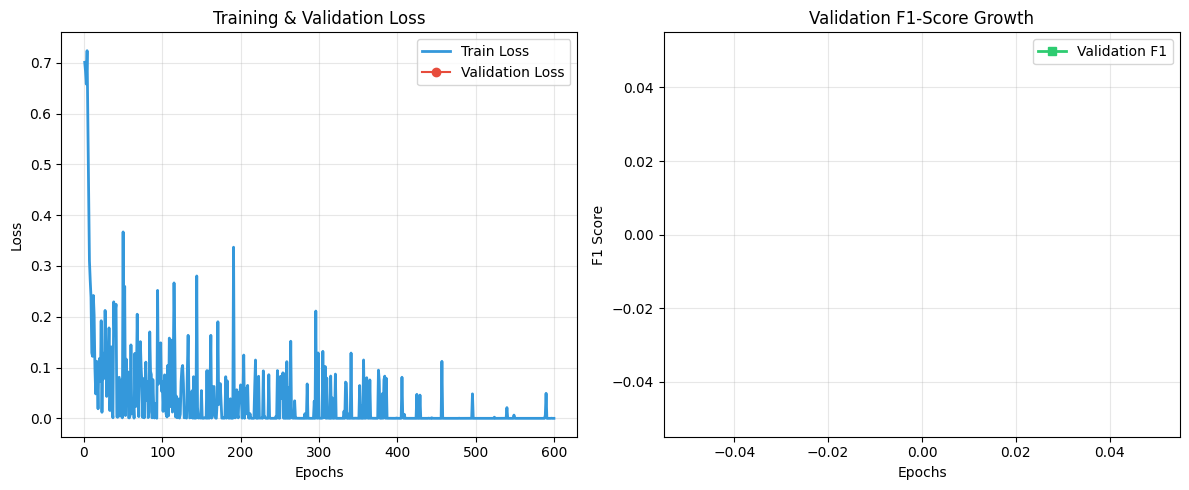

In [25]:
history = winner_trainer.state.log_history

train_loss = [log['loss'] for log in history if 'loss' in log]
eval_loss = [log['eval_loss'] for log in history if 'eval_loss' in log]
eval_f1 = [log['eval_f1'] for log in history if 'eval_f1' in log]
epochs = [log['epoch'] for log in history if 'eval_loss' in log]

plt.figure(figsize=(12, 5))

# Loss Curve
plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Train Loss', color='#3498db', linewidth=2)
plt.plot(epochs, eval_loss, label='Validation Loss', color='#e74c3c', marker='o')
plt.title('Training & Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)

# F1 Score Curve
plt.subplot(1, 2, 2)
plt.plot(epochs, eval_f1, label='Validation F1', color='#2ecc71', marker='s', linewidth=2)
plt.title('Validation F1-Score Growth')
plt.xlabel('Epochs')
plt.ylabel('F1 Score')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

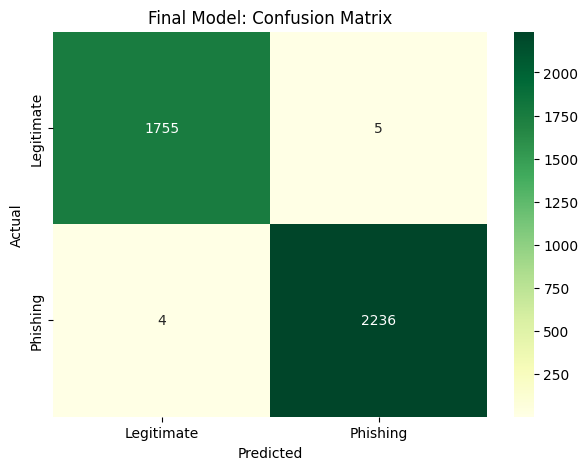


Detailed Classification Report:
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00      1760
    Phishing       1.00      1.00      1.00      2240

    accuracy                           1.00      4000
   macro avg       1.00      1.00      1.00      4000
weighted avg       1.00      1.00      1.00      4000



In [26]:
y_true = test_results.label_ids
y_pred = np.argmax(test_results.predictions, axis=-1)

# Confusion Matrix
plt.figure(figsize=(7,5))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGn',
            xticklabels=['Legitimate', 'Phishing'],
            yticklabels=['Legitimate', 'Phishing'])
plt.title("Final Model: Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Classification Report
print("\nDetailed Classification Report:")
print(classification_report(y_true, y_pred, target_names=["Legitimate", "Phishing"]))

In [30]:
import re

def preprocess_basic(text):
    text = str(text).lower()
    text = re.sub(r'\s+', ' ', text)   # remove extra spaces
    return text

def preprocess_extended(text):
    text = re.sub(r'http\S+', '', text)   # remove urls
    text = re.sub(r'\d+', '', text)       # remove numbers
    text = re.sub(r'[^\w\s]', '', text)   # remove punctuation
    return text

In [31]:
# External Data (SpamAssassin)
df_sa = pd.read_csv(
    'SpamAssasin.csv',
    encoding='ISO-8859-1',
    on_bad_lines='skip'
).dropna(subset=['body', 'label'])

df_sa['body_clean'] = df_sa['body'].apply(preprocess_basic).apply(preprocess_extended)

# 2. Re-train the "Best" Model
best_params = study.best_params

final_args = TrainingArguments(
    output_dir="./final_bert_model",
    learning_rate=best_params["learning_rate"],
    per_device_train_batch_size=best_params["per_device_train_batch_size"],
    num_train_epochs=best_params["num_train_epochs"],
    weight_decay=best_params["weight_decay"],
    save_strategy="no",
    report_to="none"
)

final_model = AutoModelForSequenceClassification.from_pretrained("bert-base-uncased", num_labels=2)

final_trainer = Trainer(
    model=final_model,
    args=final_args,
    train_dataset=train_dataset,
    data_collator=data_collator
)

final_trainer.train()


print("--- External Validation: SpamAssassin ---")

external_encodings = tokenizer(df_sa['body_clean'].tolist(), truncation=True, padding=True)
external_dataset = EmailDataset(external_encodings, df_sa['label'].tolist())

raw_preds = final_trainer.predict(external_dataset)
y_sa_true = df_sa['label'].values
y_sa_pred = np.argmax(raw_preds.predictions, axis=-1)

sa_f1 = f1_score(y_sa_true, y_sa_pred, average='macro')
internal_f1 = study.best_value

print("\nDetailed Classification Report (External):")
print(classification_report(y_sa_true, y_sa_pred, target_names=['Legitimate', 'Phishing']))

print(f"Internal Best CV F1: {internal_f1:.4f}")
print(f"External SpamAssassin F1: {sa_f1:.4f}")
print(f"Performance Gap: {internal_f1 - sa_f1:.4f}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Step,Training Loss
500,0.133907
1000,0.068681
1500,0.058910
2000,0.035091
2500,0.014424
3000,0.022221
3500,0.019712
4000,0.007665
4500,0.003766
5000,0.002611


--- External Validation: SpamAssassin ---



Detailed Classification Report (External):
              precision    recall  f1-score   support

  Legitimate       0.99      0.07      0.13      4088
    Phishing       0.31      1.00      0.47      1688

    accuracy                           0.34      5776
   macro avg       0.65      0.53      0.30      5776
weighted avg       0.79      0.34      0.23      5776

Internal Best CV F1: 0.9972
External SpamAssassin F1: 0.3006
Performance Gap: 0.6967
